# Prédiction du Risque de Crise Cardiaque
## Pipeline complet : Preprocessing → Modélisation → Evaluation

**Dataset** : Heart Attack Risk Prediction Dataset (Kaggle — 8763 patients, 26 variables)  
**Objectif** : Prédire la variable cible `Heart Attack Risk` (0 = faible risque, 1 = risque élevé)

---
### Plan du notebook
1. Import des librairies
2. Chargement et exploration des données (EDA)
3. Preprocessing (nettoyage, encodage, scaling, outliers)
4. Split Train / Test
5. Entraînement et comparaison des modèles
6. Optimisation (GridSearchCV)
7. Evaluation complète (Matrice de confusion, ROC, F1)
8. Feature Importances
9. Validation croisée
10. Sauvegarde du meilleur modèle

## 1. Import des librairies

In [3]:
# ─────────────────────────────────────────────────────────────
# SECTION 1 : Import de toutes les librairies nécessaires
# ─────────────────────────────────────────────────────────────

# Librairies de base pour la manipulation et le calcul
import numpy as np          # calculs numériques (tableaux, statistiques)
import pandas as pd         # manipulation des données en tableaux (DataFrames)

# Librairies de visualisation
import matplotlib.pyplot as plt   # création de graphiques
import seaborn as sns             # graphiques statistiques avancés (sur matplotlib)

# Gestion des avertissements Python
import warnings
warnings.filterwarnings('ignore')  # masque les alertes non critiques pour plus de lisibilité

# Traitement des valeurs extrêmes (outliers)
from scipy.stats.mstats import winsorize  # winsorization = plafonner les valeurs extrêmes

# Preprocessing (prétraitement des données)
from sklearn.preprocessing import LabelEncoder, RobustScaler
# LabelEncoder : convertit les textes (ex: "Male"/"Female") en chiffres (0/1)
# RobustScaler : normalise les données en utilisant la médiane — résistant aux outliers

# Découpage et validation du dataset
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
# train_test_split : divise les données en jeu d'entraînement et jeu de test
# GridSearchCV    : cherche automatiquement les meilleurs hyperparamètres
# cross_val_score : évalue le modèle sur plusieurs découpages (validation croisée)

# Modèles de machine learning
from sklearn.linear_model import LogisticRegression          # régression logistique
from sklearn.tree import DecisionTreeClassifier              # arbre de décision
from sklearn.ensemble import (
    RandomForestClassifier,     # forêt aléatoire (ensemble d'arbres)
    BaggingClassifier,          # méthode Bagging (bootstrap aggregating)
    AdaBoostClassifier,         # méthode Boosting adaptatif
    GradientBoostingClassifier  # gradient boosting
)
from sklearn.neighbors import KNeighborsClassifier  # K plus proches voisins
from xgboost import XGBClassifier                   # XGBoost — meilleur algo sur données tabulaires

# Métriques d'évaluation des modèles
from sklearn.metrics import (
    accuracy_score,        # taux de bonnes prédictions
    roc_auc_score,         # aire sous la courbe ROC (mesure de discrimination)
    roc_curve,             # coordonnées de la courbe ROC
    classification_report, # tableau précision / rappel / F1 par classe
    confusion_matrix,      # matrice de confusion (vrais/faux positifs et négatifs)
    ConfusionMatrixDisplay, # affichage graphique de la matrice de confusion
    f1_score               # F1-score = moyenne harmonique précision/rappel
)

# Sauvegarde du modèle entraîné sur disque
import joblib

# Style des graphiques
plt.rcParams['figure.figsize'] = [15, 6]  # taille par défaut des figures
sns.set_style('whitegrid')                # fond blanc avec grille pour les graphiques

print("✓ Toutes les librairies sont chargées avec succès.")

✓ Toutes les librairies sont chargées avec succès.


## 2. Chargement et exploration des données (EDA)

In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 : Chargement du dataset
# ─────────────────────────────────────────────────────────────

# Charger le fichier CSV dans un DataFrame pandas
# Le fichier doit être dans le même dossier que ce notebook
df = pd.read_csv('heart_attack_prediction_dataset.csv')

# Afficher les dimensions du dataset
print(f"Dimensions : {df.shape[0]} lignes (patients) × {df.shape[1]} colonnes (variables)")

# Afficher les 5 premières lignes pour avoir un aperçu visuel
df.head()

Dimensions : 8763 lignes (patients) × 26 colonnes (variables)


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [5]:
# ─────────────────────────────────────────────────────────────
# Informations générales sur les colonnes
# ─────────────────────────────────────────────────────────────

# df.info() donne pour chaque colonne :
# - le type de données (int, float, object)
# - le nombre de valeurs non nulles (pour détecter les valeurs manquantes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [6]:
# ─────────────────────────────────────────────────────────────
# Vérification des valeurs manquantes
# ─────────────────────────────────────────────────────────────

# isnull() retourne True pour chaque cellule vide
# .sum() compte le nombre de True par colonne
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Une valeur manquante = données absentes pour ce patient
# Si ce nombre est élevé, il faut imputer ou supprimer la colonne

Valeurs manquantes par colonne :
Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype

In [7]:
# ─────────────────────────────────────────────────────────────
# Vérification des doublons
# ─────────────────────────────────────────────────────────────

# duplicated() retourne True pour les lignes identiques
# .sum() donne le total de doublons
print("Nombre de lignes dupliquées :", df.duplicated().sum())
# Si > 0, il faudrait les supprimer avec df.drop_duplicates()

Nombre de lignes dupliquées : 0


In [7]:
# ─────────────────────────────────────────────────────────────
# Statistiques descriptives des variables numériques
# ─────────────────────────────────────────────────────────────

# describe() calcule automatiquement pour chaque variable numérique :
# count (nombre de valeurs), mean (moyenne), std (écart-type),
# min, 25%, 50% (médiane), 75%, max
# Cela permet de repérer des anomalies : valeurs hors bornes, distributions asymétriques
df.describe().round(2)

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.00,8763.00,8763.00,8763.00,8763.00,8763.0,8763.0,8763.00,8763.00,8763.0,8763.0,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00
mean,53.71,259.88,75.02,0.65,0.49,0.9,0.5,0.60,10.01,0.5,0.5,5.47,5.99,158263.18,28.89,417.68,3.49,7.02,0.36
std,21.25,80.86,20.55,0.48,0.50,0.3,0.5,0.49,5.78,0.5,0.5,2.86,3.47,80575.19,6.32,223.75,2.28,1.99,0.48
min,18.00,120.00,40.00,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,1.00,0.00,20062.00,18.00,30.00,0.00,4.00,0.00
25%,35.00,192.00,57.00,0.00,0.00,1.0,0.0,0.00,4.98,0.0,0.0,3.00,3.00,88310.00,23.42,225.50,2.00,5.00,0.00
50%,54.00,259.00,75.00,1.00,0.00,1.0,1.0,1.00,10.07,0.0,0.0,5.00,5.93,157866.00,28.77,417.00,3.00,7.00,0.00
75%,72.00,330.00,93.00,1.00,1.00,1.0,1.0,1.00,15.05,1.0,1.0,8.00,9.02,227749.00,34.32,612.00,5.00,9.00,1.00
max,90.00,400.00,110.00,1.00,1.00,1.0,1.0,1.00,20.00,1.0,1.0,10.00,12.00,299954.00,40.00,800.00,7.00,10.00,1.00


## 3. Analyse exploratoire (EDA)
### 3.1 Distribution de la variable cible

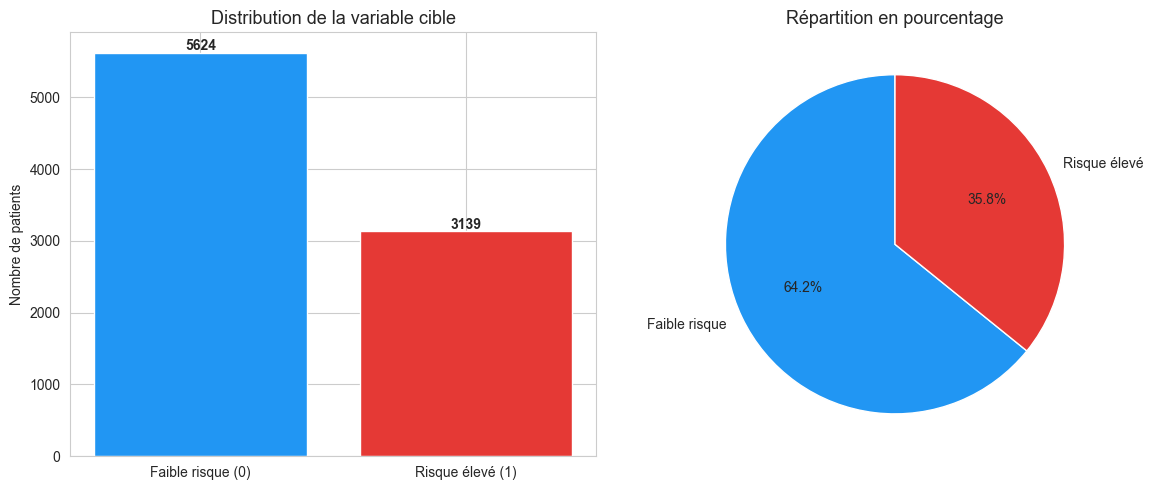

In [8]:
# ─────────────────────────────────────────────────────────────
# Distribution de la variable cible : Heart Attack Risk
# 0 = patient à faible risque
# 1 = patient à risque élevé de crise cardiaque
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Compter le nombre de patients dans chaque classe
counts = df['Heart Attack Risk'].value_counts()

# Graphique en barres : nombre de patients par classe
axes[0].bar(['Faible risque (0)', 'Risque élevé (1)'],
            counts.values,
            color=['#2196F3', '#E53935'])
axes[0].set_title('Distribution de la variable cible', fontsize=13)
axes[0].set_ylabel('Nombre de patients')

# Afficher les valeurs au-dessus des barres
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Graphique camembert : proportion de chaque classe
axes[1].pie(counts.values,
            labels=['Faible risque', 'Risque élevé'],
            autopct='%1.1f%%',            # afficher les pourcentages
            colors=['#2196F3', '#E53935'],
            startangle=90)
axes[1].set_title('Répartition en pourcentage', fontsize=13)

plt.tight_layout()
plt.show()

# Un dataset équilibré aurait 50% dans chaque classe
# Si très déséquilibré (ex: 90/10), le modèle peut avoir un biais vers la classe majoritaire

### 3.2 Variables numériques — distributions par classe

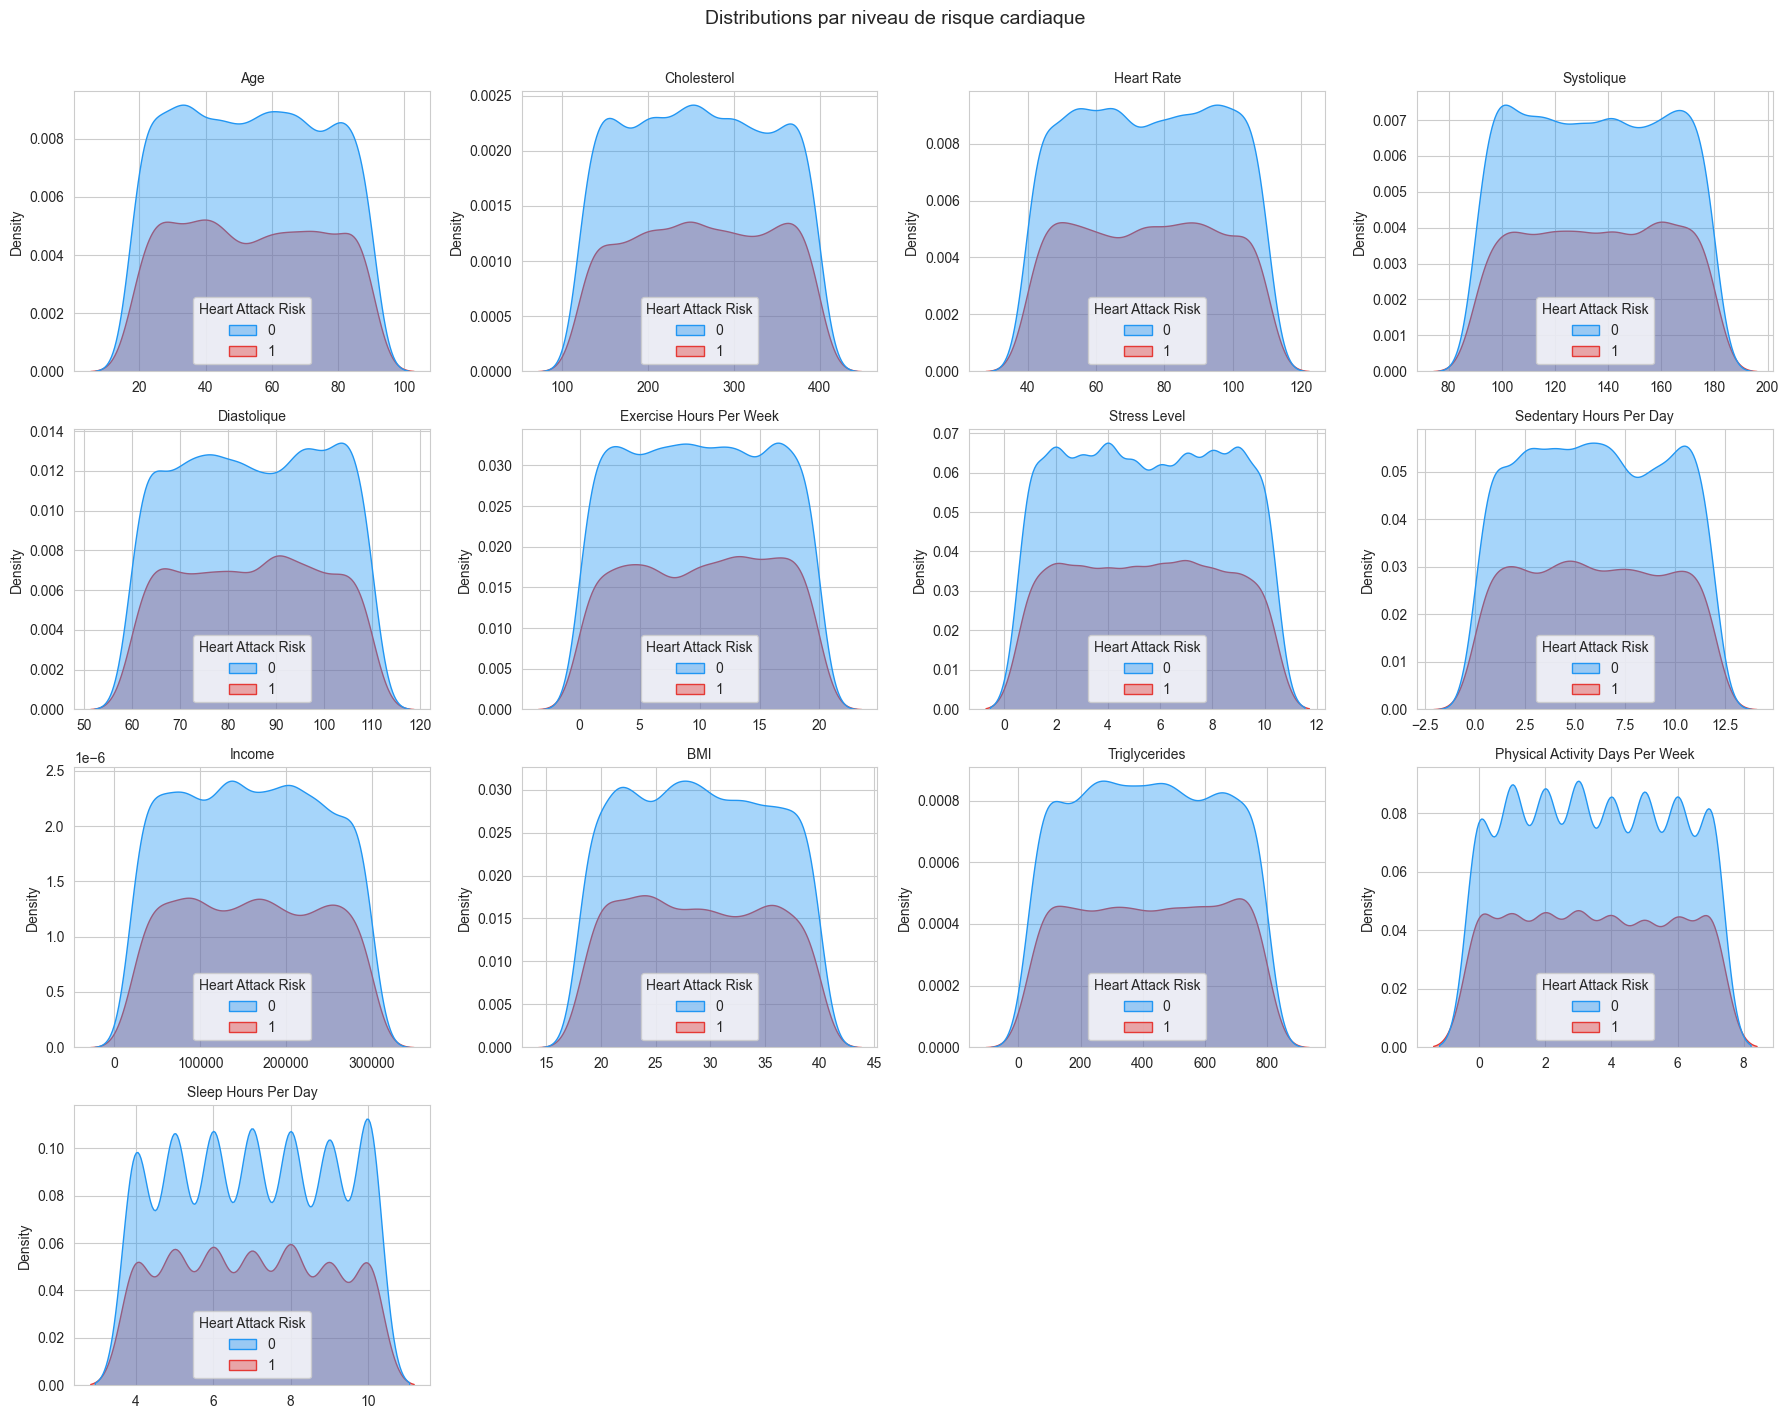

In [9]:
# ─────────────────────────────────────────────────────────────
# Préparation : séparer Blood Pressure pour l'EDA uniquement
# Blood Pressure est sous la forme "158/88" (chaîne de caractères)
# On la sépare en Systolique (pression haute) et Diastolique (pression basse)
# pour pouvoir la visualiser — cette transformation sera refaite proprement en section 4
# ─────────────────────────────────────────────────────────────

df_eda = df.copy()  # copie pour ne pas modifier le dataset original
df_eda[['Systolique', 'Diastolique']] = (
    df_eda['Blood Pressure'].str.split('/', expand=True).astype(int)
)

# Liste des variables numériques à visualiser
num_cols = ['Age', 'Cholesterol', 'Heart Rate', 'Systolique', 'Diastolique',
            'Exercise Hours Per Week', 'Stress Level', 'Sedentary Hours Per Day',
            'Income', 'BMI', 'Triglycerides',
            'Physical Activity Days Per Week', 'Sleep Hours Per Day']

r, c = 4, 4  # 4 lignes × 4 colonnes de sous-graphiques
fig, axes = plt.subplots(r, c, figsize=(18, 14))
axes = axes.flatten()  # aplatir en liste pour itérer facilement

for it, col in enumerate(num_cols):
    # KDE plot (courbe de densité) pour chaque variable
    # hue='Heart Attack Risk' trace une courbe par classe (0 et 1)
    # Cela permet de voir si la variable sépare bien les deux groupes
    sns.kdeplot(data=df_eda, x=col, hue='Heart Attack Risk',
                ax=axes[it], fill=True, alpha=0.4,
                palette={0: '#2196F3', 1: '#E53935'})
    axes[it].set_title(col, fontsize=10)
    axes[it].set_xlabel('')

# Masquer les sous-graphiques vides
for j in range(it + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions par niveau de risque cardiaque', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Interprétation : si les deux courbes se chevauchent peu → variable discriminante
# Si elles se superposent complètement → variable peu utile pour le modèle

### 3.3 Boxplots — détection des outliers par classe

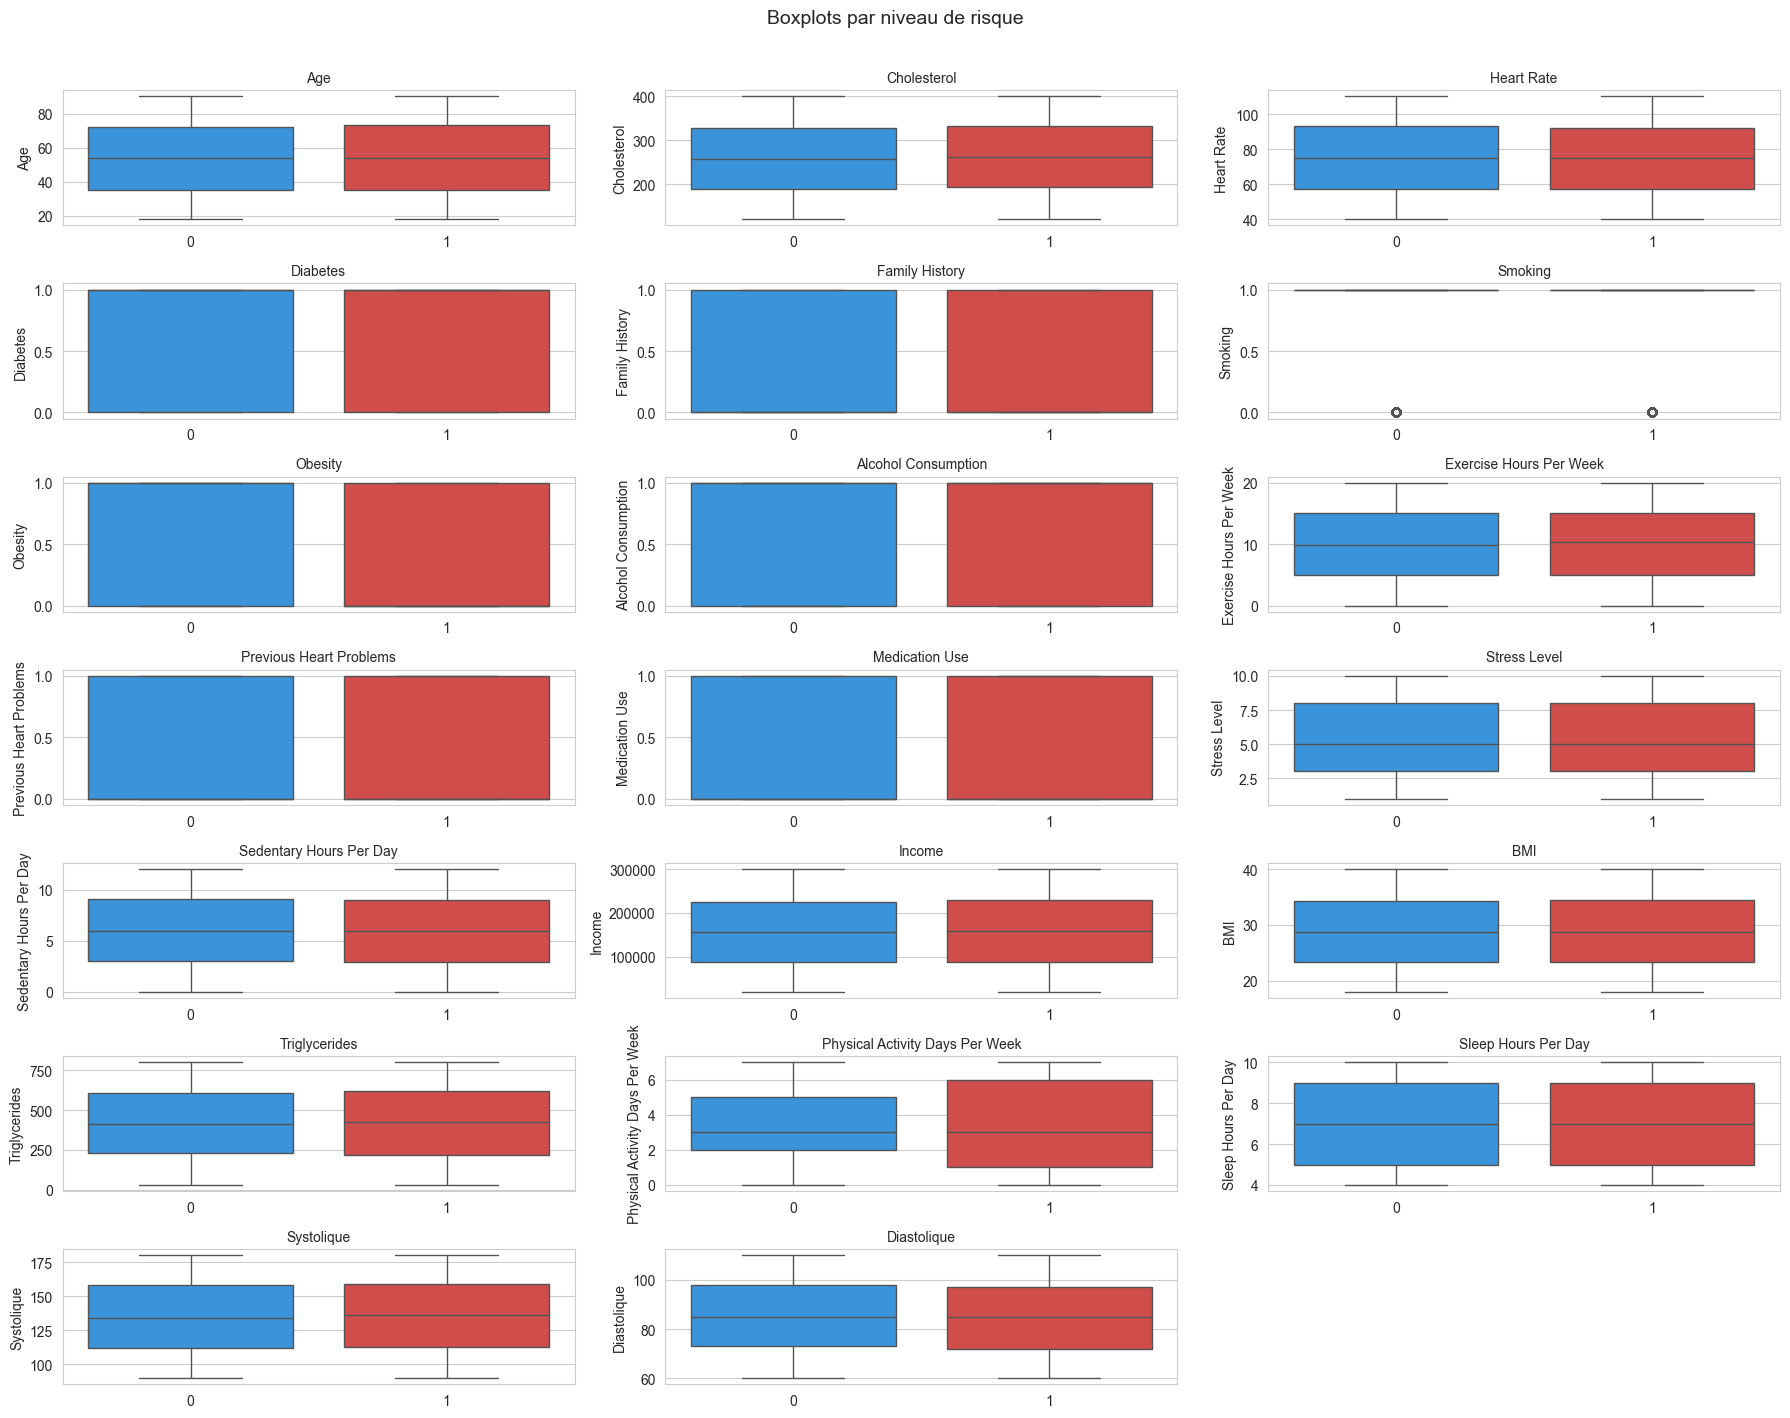

In [10]:
import math

# ── Créer df_eda à partir de ton DataFrame principal ──
df_eda = df.copy()
df_eda[['Systolique', 'Diastolique']] = (
    df_eda['Blood Pressure'].str.split('/', expand=True).astype(int)
)

# ─────────────────────────────────────────────────────────────
# Boxplots pour deux objectifs simultanés :
# 1. Détecter les valeurs aberrantes (points isolés au-delà des moustaches)
# 2. Comparer les distributions entre patients sains et à risque
# ─────────────────────────────────────────────────────────────

num_cols = df_eda.select_dtypes(include='number').columns.tolist()
num_cols = [col for col in num_cols if col != 'Heart Attack Risk']

c = 3
r = math.ceil(len(num_cols) / c)

fig, axes = plt.subplots(r, c, figsize=(18, 14))
axes = axes.flatten()

for it, col in enumerate(num_cols):
    sns.boxplot(data=df_eda, x='Heart Attack Risk', y=col,
                ax=axes[it], palette=['#2196F3', '#E53935'], order=[0, 1])
    axes[it].set_title(col, fontsize=10)
    axes[it].set_xlabel('')

for j in range(it + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots par niveau de risque', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Variables catégorielles

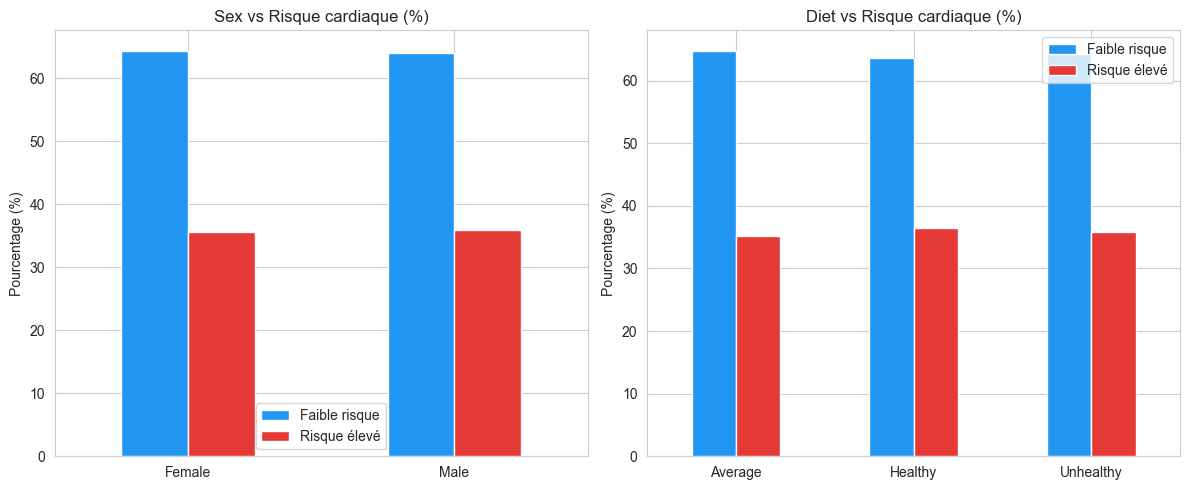

In [11]:
# ─────────────────────────────────────────────────────────────
# Analyser les variables textuelles : Sex et Diet
# On calcule le % de risque élevé dans chaque catégorie
# ─────────────────────────────────────────────────────────────

cat_cols = ['Sex', 'Diet']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for it, col in enumerate(cat_cols):
    # crosstab crée un tableau croisé : chaque ligne = une modalité de la variable
    # normalize='index' calcule les proportions par ligne (somme = 100% par ligne)
    ct = pd.crosstab(df[col], df['Heart Attack Risk'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[it],
            color=['#2196F3', '#E53935'],
            edgecolor='white')
    axes[it].set_title(f'{col} vs Risque cardiaque (%)', fontsize=12)
    axes[it].set_xlabel('')
    axes[it].set_ylabel('Pourcentage (%)')
    axes[it].legend(['Faible risque', 'Risque élevé'])
    axes[it].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.5 Matrice de corrélation

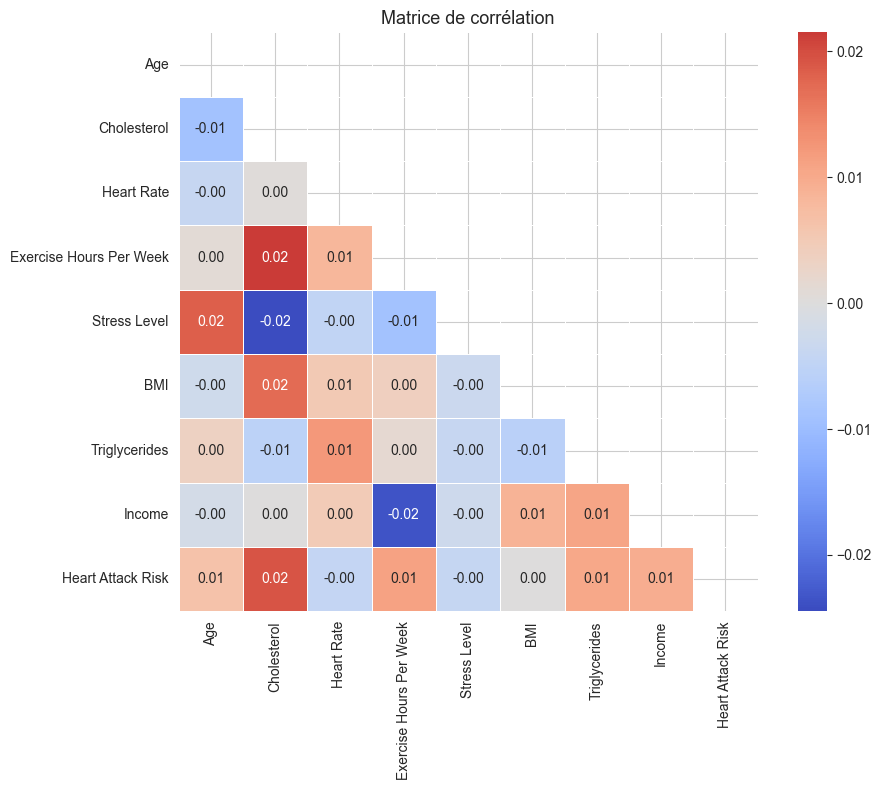

In [12]:
# ─────────────────────────────────────────────────────────────
# Matrice de corrélation entre variables numériques
# Objectif : identifier les variables fortement liées entre elles
# et les variables corrélées avec la cible (Heart Attack Risk)
# ─────────────────────────────────────────────────────────────

corr_cols = ['Age', 'Cholesterol', 'Heart Rate',
             'Exercise Hours Per Week', 'Stress Level', 'BMI',
             'Triglycerides', 'Income', 'Heart Attack Risk']

plt.figure(figsize=(10, 8))

# Calculer la matrice de corrélation (coefficients de Pearson entre -1 et 1)
# +1 = forte corrélation positive | -1 = forte corrélation négative | 0 = aucune relation
corr = df_eda[corr_cols].corr()

# Masquer le triangle supérieur (symétrique) pour plus de lisibilité
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask,
            annot=True,     # afficher les valeurs dans chaque cellule
            fmt='.2f',      # 2 décimales
            cmap='coolwarm', # rouge = corrélation positive, bleu = négative
            center=0,        # 0 = blanc (pas de corrélation)
            square=True,
            linewidths=0.5)
plt.title('Matrice de corrélation', fontsize=13)
plt.tight_layout()
plt.show()

# Lire la dernière colonne/ligne pour voir quelles variables
# sont le plus corrélées avec Heart Attack Risk

## 4. Preprocessing
### 4.1 Suppression des colonnes non informatives

In [13]:
# ─────────────────────────────────────────────────────────────
# Supprimer les colonnes qui n'apportent aucune information
# prédictive au modèle :
# - Patient ID  : identifiant unique, ne prédit rien
# - Country     : trop granulaire, redondant avec Continent
# - Continent   : information géographique non clinique
# - Hemisphere  : inutile pour la prédiction médicale
# ─────────────────────────────────────────────────────────────

df = df.drop(['Patient ID', 'Country', 'Continent', 'Hemisphere'], axis=1)

print(f"Colonnes restantes : {df.shape[1]}")
print(df.columns.tolist())

Colonnes restantes : 22
['Age', 'Sex', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Heart Attack Risk']


### 4.2 Transformation Blood Pressure

In [10]:
# ─────────────────────────────────────────────────────────────
# Blood Pressure est une chaîne de caractères : "158/88"
# 158 = pression systolique (cœur en contraction)
# 88  = pression diastolique (cœur au repos)
#
# Le notebook original créait un ratio sys/dia
# → PROBLÈME : le ratio perd l'information individuelle de chaque mesure
# → SOLUTION : créer deux colonnes distinctes — plus riche pour le modèle
# ─────────────────────────────────────────────────────────────

# Séparer la chaîne "158/88" en deux colonnes numériques
df[['Systolique', 'Diastolique']] = (
    df['Blood Pressure']
    .str.split('/', expand=True)  # séparer par le "/"
    .astype(int)                  # convertir en entiers
)

# Supprimer la colonne originale (chaîne de caractères) devenue inutile
df = df.drop('Blood Pressure', axis=1)

print("Blood Pressure séparé en deux colonnes : Systolique et Diastolique")
print(f"Nouvelles dimensions du dataset : {df.shape}")
df[['Systolique', 'Diastolique']].describe().round(2)

Blood Pressure séparé en deux colonnes : Systolique et Diastolique
Nouvelles dimensions du dataset : (8763, 27)


,Systolique,Diastolique
count,8763.00,8763.00
mean,135.08,85.16
std,26.35,14.68
min,90.00,60.00
25%,112.00,72.00
50%,135.00,85.00
75%,158.00,98.00
max,180.00,110.00


### 4.3 Encodage des variables catégorielles
> **Correction du notebook original** : le Target Encoding calculé sur tout le dataset avant le split introduit un **data leakage** (fuite d'information de la cible vers les features). On utilise ici un encodage simple et propre.

In [11]:
# ─────────────────────────────────────────────────────────────
# Encodage des variables textuelles → valeurs numériques
#
# Les modèles de machine learning ne peuvent pas traiter du texte
# Il faut convertir chaque catégorie en nombre
#
# POURQUOI PAS LE TARGET ENCODING ?
# Le Target Encoding remplace chaque catégorie par le taux moyen
# de la variable cible dans ce groupe.
# Si calculé avant le split, le modèle "voit" indirectement y dans X
# → biais appelé data leakage → scores artificiellement gonflés
# ─────────────────────────────────────────────────────────────

le = LabelEncoder()  # instancier l'encodeur

# ── Variable Sex ──────────────────────────────────────────────
# LabelEncoder assigne automatiquement : Female=0, Male=1
df['Sex'] = le.fit_transform(df['Sex'])
print("Encodage Sex :", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Variable Diet ─────────────────────────────────────────────
# On utilise un encodage ordonné logique (ordinale) :
# Healthy (sain) = 0 | Average (moyen) = 1 | Unhealthy (malsain) = 2
# Cette progression reflète un gradient de risque croissant
diet_map = {'Healthy': 0, 'Average': 1, 'Unhealthy': 2}
df['Diet'] = df['Diet'].map(diet_map)
print("Encodage Diet :", diet_map)

# Vérification
print("\nAperçu après encodage :")
df[['Sex', 'Diet']].head()

Encodage Sex : {'Female': np.int64(0), 'Male': np.int64(1)}
Encodage Diet : {'Healthy': 0, 'Average': 1, 'Unhealthy': 2}

Aperçu après encodage :


,Sex,Diet
0,1,1
1,1,2
2,0,0
3,1,1
4,1,2


### 4.4 Traitement des outliers — Winsorization

In [12]:
# ─────────────────────────────────────────────────────────────
# WINSORIZATION : plafonner les valeurs extrêmes
#
# Principe : au lieu de supprimer les outliers, on les remplace
# par les valeurs aux percentiles 1% et 99%
# Ex: si Cholesterol 99e percentile = 350, toute valeur > 350 → 350
#
# Pourquoi winsoriser ici ?
# - Income peut atteindre plusieurs millions
# - Triglycerides peut avoir des pics très élevés
# - Ces extrêmes perturbent le scaling et certains modèles
#
# Limite = 0.01 signifie : plafonner les 1% inférieurs ET les 1% supérieurs
# ─────────────────────────────────────────────────────────────

# Variables qui présentent des outliers significatifs (détectés dans les boxplots)
cols_winsorize = ['Cholesterol', 'Triglycerides', 'Income', 'BMI',
                  'Systolique', 'Diastolique']

# Enregistrer les min/max avant winsorization pour comparaison
df_avant = df[cols_winsorize].agg(['min', 'max']).round(2)

# Appliquer la winsorization colonne par colonne
for col in cols_winsorize:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

# Enregistrer les min/max après winsorization
df_apres = df[cols_winsorize].agg(['min', 'max']).round(2)

print("AVANT winsorization :")
print(df_avant)
print("\nAPRES winsorization :")
print(df_apres)
print("\nLes valeurs extrêmes ont été plafonnées.")

AVANT winsorization :
     Cholesterol  Triglycerides  Income   BMI  Systolique  Diastolique
min          120             30   20062  18.0          90           60
max          400            800  299954  40.0         180          110

APRES winsorization :
     Cholesterol  Triglycerides  Income    BMI  Systolique  Diastolique
min          122             37   22462  18.24          90           60
max          398            794  297079  39.81         180          110

Les valeurs extrêmes ont été plafonnées.


### 4.5 Séparation X / y

In [13]:
# ─────────────────────────────────────────────────────────────
# Séparation en X (features = variables d'entrée)
# et y (target = variable à prédire)
#
# X contient toutes les colonnes SAUF la cible
# y contient UNIQUEMENT la colonne cible
# ─────────────────────────────────────────────────────────────

X = df.drop('Heart Attack Risk', axis=1)  # features : tout sauf la cible
y = df['Heart Attack Risk']               # cible : 0 ou 1

print(f"X — dimensions : {X.shape}  (patients × variables)")
print(f"y — dimensions : {y.shape}  (un label par patient)")
print(f"\nDistribution de la cible :")
print(y.value_counts())
print(f"\nProportion de cas positifs : {y.mean():.1%}")

X — dimensions : (8763, 26)  (patients × variables)
y — dimensions : (8763,)  (un label par patient)

Distribution de la cible :
Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

Proportion de cas positifs : 35.8%


## 5. Split Train / Test


In [14]:
# ─────────────────────────────────────────────────────────────
# SPLIT TRAIN / TEST
#
# Principe : diviser le dataset en deux parties
# - Train (70%) : données sur lesquelles le modèle APPREND
# - Test  (30%) : données INCONNUES pour évaluer le modèle
#
# Paramètres importants :
# test_size=0.30   → 30% des données pour le test
# random_state=42  → graine aléatoire : résultats reproductibles
# stratify=y       → CRUCIAL : garantit que la proportion 0/1
#                   est identique dans train et test
#                   Sans stratify, si le dataset est déséquilibré,
#                   le split peut être biaisé
# ─────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # préserver la distribution des classes dans chaque split
)

print(f"Train : {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} patients ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribution y_train : {y_train.value_counts().to_dict()}")
print(f"Distribution y_test  : {y_test.value_counts().to_dict()}")
print(f"\nProportion train : {y_train.mean():.3f} | Proportion test : {y_test.mean():.3f}")
# Les proportions doivent être quasi-identiques grâce à stratify

Train : 6134 patients (70.0%)
Test  : 2629 patients (30.0%)

Distribution y_train : {0: 3937, 1: 2197}
Distribution y_test  : {0: 1687, 1: 942}

Proportion train : 0.358 | Proportion test : 0.358


### 5.1 Scaling — RobustScaler

In [15]:
# ─────────────────────────────────────────────────────────────
# SCALING : mise à l'échelle des variables numériques
#
# Problème : les variables ont des échelles très différentes
# - Age         : 18 à 90
# - Income      : des milliers ou millions
# - Stress Level: 1 à 10
# Les modèles sensibles aux distances (KNN, SVM, LR, réseaux de neurones)
# seraient dominés par les grandes valeurs sans scaling
#
# Pourquoi RobustScaler plutôt que StandardScaler ?
# - StandardScaler utilise la moyenne et l'écart-type
#   → très sensible aux outliers (même après winsorization)
# - RobustScaler utilise la MÉDIANE et l'écart interquartile (Q1-Q3)
#   → robuste aux valeurs extrêmes restantes
#
# RÈGLE IMPORTANTE : le scaler est ajusté (fit) UNIQUEMENT sur X_train
# puis appliqué (transform) sur X_train ET X_test
# Si on fittait sur tout le dataset, on introduirait un data leakage
# (les statistiques du test contamineraient l'entraînement)
# ─────────────────────────────────────────────────────────────

# Colonnes continues à normaliser (les binaires 0/1 n'ont pas besoin de scaling)
cols_scale = [
    'Age', 'Cholesterol', 'Heart Rate',
    'Exercise Hours Per Week', 'Stress Level',
    'Sedentary Hours Per Day', 'Income', 'BMI',
    'Triglycerides', 'Physical Activity Days Per Week',
    'Sleep Hours Per Day', 'Systolique', 'Diastolique'
]

# Instancier le scaler
scaler = RobustScaler()

# fit_transform sur X_train : apprendre les statistiques (médiane, IQR) ET transformer
X_train[cols_scale] = scaler.fit_transform(X_train[cols_scale])

# transform uniquement sur X_test : appliquer les mêmes statistiques du train
# On NE refit PAS sur X_test
X_test[cols_scale] = scaler.transform(X_test[cols_scale])

print("Scaling appliqué avec succès (RobustScaler)")
print("\nAperçu de X_train après scaling :")
X_train.head()

Scaling appliqué avec succès (RobustScaler)

Aperçu de X_train après scaling :


,Patient ID,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Systolique,Diastolique
865,FPU3089,-0.918919,1,0.841727,-0.555556,1,0,1,0,1,...,0.965373,0.490210,-0.540576,0.4,0.50,Canada,North America,Northern Hemisphere,-0.239130,0.461538
1817,XRU4053,-0.054054,1,0.359712,-0.388889,0,0,1,1,0,...,-0.819028,0.739139,0.789267,0.2,0.50,Italy,Europe,Southern Hemisphere,0.173913,0.576923
2673,HHO1270,0.054054,1,-0.453237,0.694444,0,1,1,0,1,...,-0.426141,0.425679,-0.595550,-0.2,0.25,Argentina,South America,Southern Hemisphere,-0.239130,-0.192308
5736,HBU8898,-0.621622,1,-0.035971,0.000000,0,1,1,1,1,...,-0.184415,-0.719548,0.943717,0.8,-0.25,United States,North America,Northern Hemisphere,-0.565217,0.769231
2605,JTC9113,-0.405405,1,0.431655,-0.222222,0,1,1,1,0,...,0.452566,0.165439,0.912304,-0.4,0.00,Nigeria,Africa,Northern Hemisphere,-0.173913,0.961538


## 6. Entraînement et comparaison des modèles
### 6.1 Fonction d'évaluation unifiée

In [16]:
# ─────────────────────────────────────────────────────────────
# FONCTION RÉUTILISABLE : evaluer_modele()
#
# Objectif : centraliser toute l'évaluation d'un modèle en une
# seule fonction pour éviter la répétition de code
#
# Pour chaque modèle, la fonction :
# 1. Entraîne le modèle sur X_train
# 2. Prédit sur X_train (train) et X_test (test)
# 3. Calcule : Accuracy, AUC-ROC, F1-Score
# 4. Affiche le rapport de classification complet
# 5. Trace la matrice de confusion
# 6. Trace la courbe ROC
# 7. Retourne un dictionnaire des métriques pour le tableau final
# ─────────────────────────────────────────────────────────────

def evaluer_modele(nom, modele, X_tr, y_tr, X_te, y_te):
    
    # ── Entraînement ────────────────────────────────────────
    modele.fit(X_tr, y_tr)  # le modèle apprend les patterns sur les données d'entraînement
    
    # ── Prédictions ─────────────────────────────────────────
    y_pred_train = modele.predict(X_tr)         # prédictions sur les données d'entraînement
    y_pred_test  = modele.predict(X_te)         # prédictions sur les données de test
    y_proba_test = modele.predict_proba(X_te)[:, 1]  # probabilités pour la classe 1 (ROC)
    
    # ── Métriques ────────────────────────────────────────────
    acc_train = accuracy_score(y_tr, y_pred_train)  # accuracy sur train
    acc_test  = accuracy_score(y_te, y_pred_test)   # accuracy sur test
    auc       = roc_auc_score(y_te, y_proba_test)   # AUC-ROC : 0.5=aléatoire, 1=parfait
    f1        = f1_score(y_te, y_pred_test)          # F1 : équilibre précision/rappel
    
    # ── Affichage des métriques ───────────────────────────────
    print(f"{'='*60}")
    print(f"  Modèle : {nom}")
    print(f"{'='*60}")
    print(f"  Accuracy Train : {acc_train:.4f}")
    print(f"  Accuracy Test  : {acc_test:.4f}")
    # Ecart Train-Test > 0.10 = overfitting (le modèle mémorise au lieu d'apprendre)
    print(f"  Gap Train-Test : {acc_train - acc_test:.4f}  {'⚠ Overfitting possible' if acc_train - acc_test > 0.10 else '✓ Stable'}")
    print(f"  AUC-ROC        : {auc:.4f}")
    print(f"  F1-Score       : {f1:.4f}")
    print()
    
    # Rapport de classification : précision, rappel, F1 pour chaque classe
    # Précision = parmi ceux qu'on dit à risque, combien l'étaient vraiment
    # Rappel    = parmi ceux vraiment à risque, combien a-t-on détectés
    print(classification_report(y_te, y_pred_test,
          target_names=['Faible risque', 'Risque élevé']))
    
    # ── Visualisations ───────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Matrice de confusion :
    # Lignes = classe réelle | Colonnes = classe prédite
    # Cellule (0,0) = Vrais Négatifs  | Cellule (0,1) = Faux Positifs
    # Cellule (1,0) = Faux Négatifs   | Cellule (1,1) = Vrais Positifs
    # En médical : les Faux Négatifs (cas à risque non détectés) sont les plus dangereux
    cm = confusion_matrix(y_te, y_pred_test)
    ConfusionMatrixDisplay(cm, display_labels=['Faible risque', 'Risque élevé']).plot(
        ax=axes[0], cmap='Blues')
    axes[0].set_title(f'Matrice de confusion — {nom}')
    
    # Courbe ROC :
    # FPR = taux de faux positifs (axe X) | TPR = taux de vrais positifs (axe Y)
    # La diagonale = modèle aléatoire (AUC=0.5)
    # Plus la courbe est en haut à gauche, meilleur est le modèle
    fpr, tpr, _ = roc_curve(y_te, y_proba_test)
    axes[1].plot(fpr, tpr, color='#E53935', lw=2, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Modèle aléatoire')
    axes[1].set_xlabel('Taux de faux positifs (FPR)')
    axes[1].set_ylabel('Taux de vrais positifs (TPR)')
    axes[1].set_title(f'Courbe ROC — {nom}')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Retourner les métriques pour le tableau comparatif final
    return {
        'Modèle':     nom,
        'Acc Train':  round(acc_train, 4),
        'Acc Test':   round(acc_test,  4),
        'AUC-ROC':    round(auc,       4),
        'F1-Score':   round(f1,        4)
    }

### 6.2 Entraînement de tous les modèles

In [17]:
# ─────────────────────────────────────────────────────────────
# Liste pour stocker les résultats de chaque modèle
# À la fin, on l'utilisera pour créer le tableau comparatif
# ─────────────────────────────────────────────────────────────
resultats = []

In [18]:
# ── Modèle 1 : Régression Logistique ─────────────────────────
# Modèle linéaire simple : cherche une frontière linéaire entre les classes
# Avantage : rapide, interprétable
# Limite    : ne capture pas les relations non-linéaires
# max_iter=1000 : augmenter le nombre d'itérations pour assurer la convergence
res = evaluer_modele(
    "Régression Logistique",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test
)
resultats.append(res)

ValueError: could not convert string to float: 'FPU3089'

  Modèle : Decision Tree
  Accuracy Train : 1.0000
  Accuracy Test  : 0.5261
  Gap Train-Test : 0.4739  ⚠ Overfitting possible
  AUC-ROC        : 0.4915
  F1-Score       : 0.3584

               precision    recall  f1-score   support

Faible risque       0.64      0.61      0.62      1687
 Risque élevé       0.35      0.37      0.36       942

     accuracy                           0.53      2629
    macro avg       0.49      0.49      0.49      2629
 weighted avg       0.53      0.53      0.53      2629



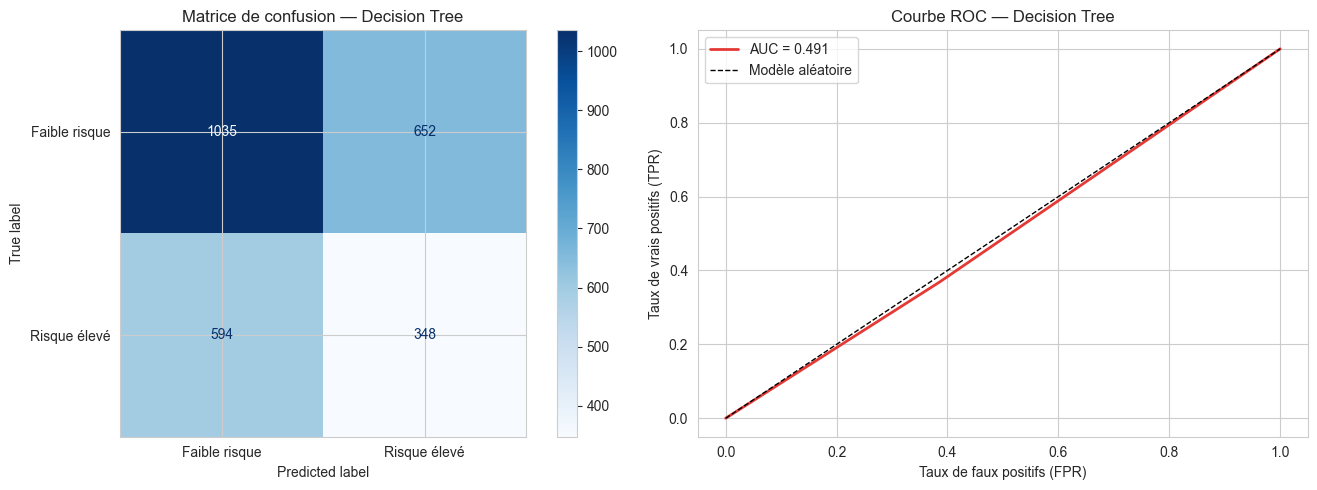

In [23]:
# ── Modèle 2 : Decision Tree ──────────────────────────────────
# Arbre de décision : pose des questions successives sur les variables
# Ex: "Cholesterol > 250 ?" → "Oui" → "Age > 60 ?" → ...
# Avantage : très interprétable, visuel
# Limite    : fortement sujet à l'overfitting sans contraintes
res = evaluer_modele(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    X_train, y_train, X_test, y_test
)
resultats.append(res)

  Modèle : Random Forest
  Accuracy Train : 1.0000
  Accuracy Test  : 0.6383
  Gap Train-Test : 0.3617  ⚠ Overfitting possible
  AUC-ROC        : 0.4961
  F1-Score       : 0.0537

               precision    recall  f1-score   support

Faible risque       0.64      0.98      0.78      1687
 Risque élevé       0.43      0.03      0.05       942

     accuracy                           0.64      2629
    macro avg       0.54      0.50      0.42      2629
 weighted avg       0.57      0.64      0.52      2629



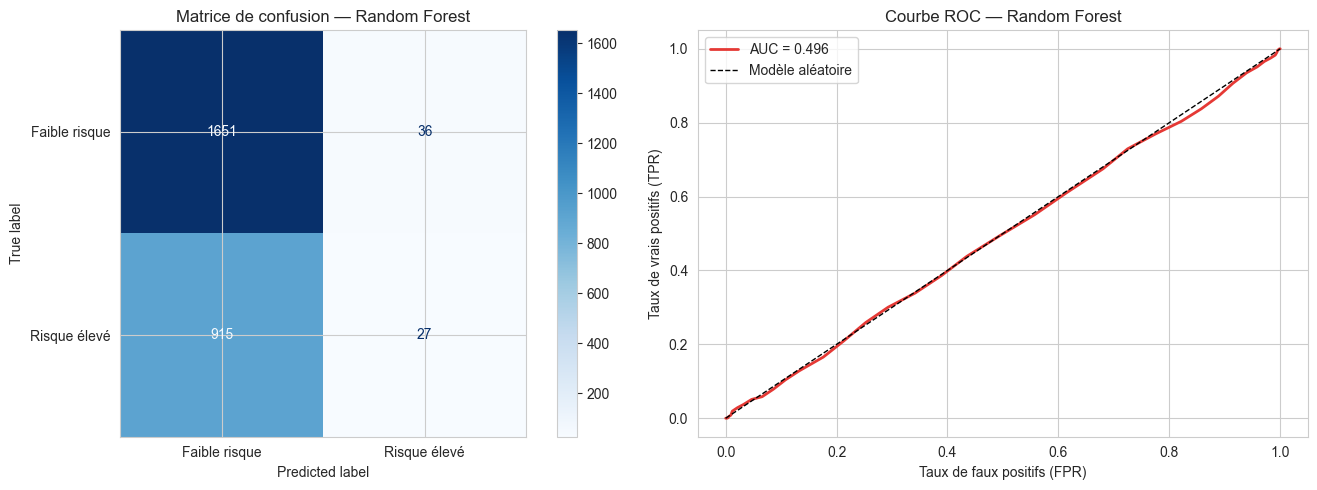

In [24]:
# ── Modèle 3 : Random Forest ──────────────────────────────────
# Ensemble de N arbres de décision entraînés sur des sous-échantillons
# Chaque arbre vote, la classe majoritaire est retenue
# Avantage : robuste à l'overfitting, gère bien les données bruitées
# n_estimators=100 : 100 arbres dans la forêt
res = evaluer_modele(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train, X_test, y_test
)
resultats.append(res)

  Modèle : KNN
  Accuracy Train : 0.6920
  Accuracy Test  : 0.5862
  Gap Train-Test : 0.1059  ⚠ Overfitting possible
  AUC-ROC        : 0.5071
  F1-Score       : 0.2649

               precision    recall  f1-score   support

Faible risque       0.64      0.80      0.71      1687
 Risque élevé       0.36      0.21      0.26       942

     accuracy                           0.59      2629
    macro avg       0.50      0.50      0.49      2629
 weighted avg       0.54      0.59      0.55      2629



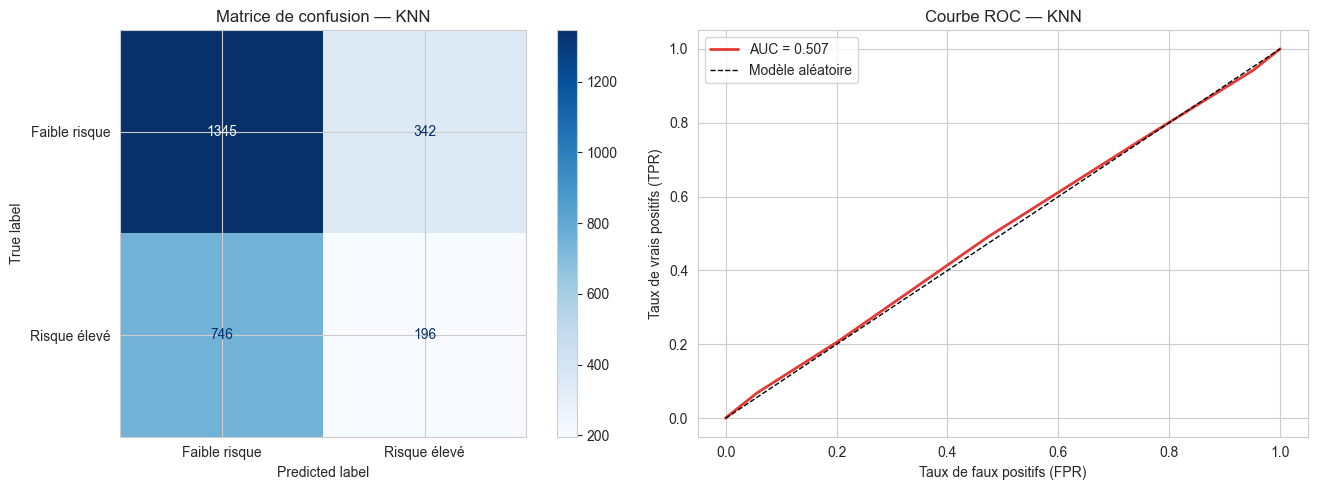

In [25]:
# ── Modèle 4 : KNN (K plus proches voisins) ───────────────────
# Pour chaque nouveau patient, regarde les K patients les plus
# similaires dans les données d'entraînement et prédit la classe majoritaire
# Avantage : simple, pas d'hypothèse sur la distribution
# Limite    : lent sur grands datasets, sensible aux échelles (d'où le scaling)
# n_neighbors=7 : considérer les 7 voisins les plus proches
res = evaluer_modele(
    "KNN",
    KNeighborsClassifier(n_neighbors=7),
    X_train, y_train, X_test, y_test
)
resultats.append(res)

  Modèle : Gradient Boosting
  Accuracy Train : 0.6739
  Accuracy Test  : 0.6371
  Gap Train-Test : 0.0368  ✓ Stable
  AUC-ROC        : 0.5173
  F1-Score       : 0.0610

               precision    recall  f1-score   support

Faible risque       0.64      0.97      0.78      1687
 Risque élevé       0.42      0.03      0.06       942

     accuracy                           0.64      2629
    macro avg       0.53      0.50      0.42      2629
 weighted avg       0.56      0.64      0.52      2629



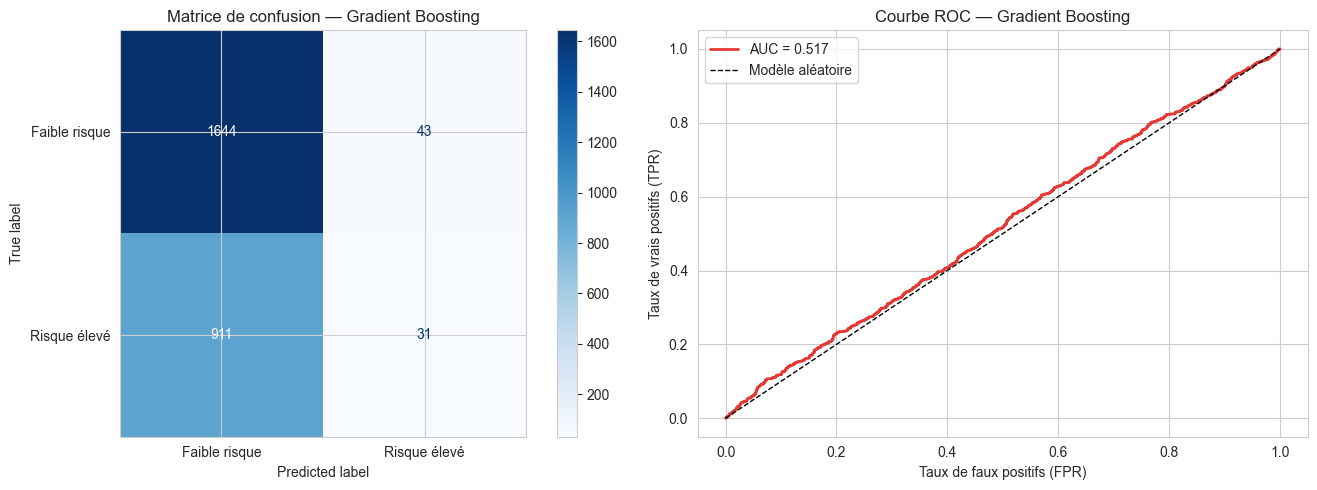

In [26]:
# ── Modèle 5 : Gradient Boosting ─────────────────────────────
# Construit les arbres séquentiellement : chaque arbre corrige
# les erreurs du précédent (boosting)
# Plus lent que Random Forest mais souvent plus précis
# n_estimators=100 : 100 arbres construits en séquence
res = evaluer_modele(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train, y_train, X_test, y_test
)
resultats.append(res)

  Modèle : XGBoost
  Accuracy Train : 0.7075
  Accuracy Test  : 0.6417
  Gap Train-Test : 0.0658  ✓ Stable
  AUC-ROC        : 0.5174
  F1-Score       : 0.1063

               precision    recall  f1-score   support

Faible risque       0.65      0.97      0.78      1687
 Risque élevé       0.50      0.06      0.11       942

     accuracy                           0.64      2629
    macro avg       0.57      0.51      0.44      2629
 weighted avg       0.59      0.64      0.54      2629



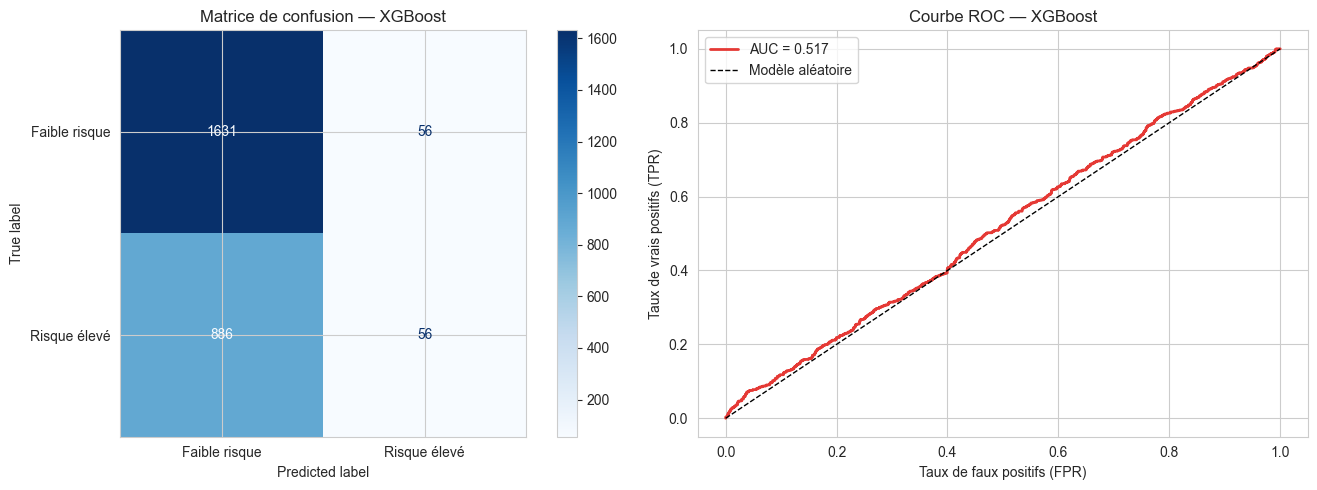

In [27]:
# ── Modèle 6 : XGBoost ────────────────────────────────────────
# Version optimisée du Gradient Boosting
# Avantages : régularisation intégrée, très rapide, meilleure gestion de l'overfitting
# C'est le modèle de référence sur les données tabulaires structurées
#
# Paramètres :
# n_estimators=200 : 200 arbres
# max_depth=4      : profondeur maximale de chaque arbre (contrôle la complexité)
# learning_rate=0.05 : pas d'apprentissage faible → apprentissage plus stable
# eval_metric='logloss' : métrique d'optimisation interne (log loss pour classification)
res = evaluer_modele(
    "XGBoost",
    XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                  eval_metric='logloss', random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test
)
resultats.append(res)

## 7. Optimisation — GridSearchCV
### 7.1 Random Forest

In [28]:
# ─────────────────────────────────────────────────────────────
# GRIDSEARCHCV : recherche automatique des meilleurs hyperparamètres
#
# Principe : on définit une grille de combinaisons de paramètres
# GridSearch teste TOUTES les combinaisons avec validation croisée
# et retourne la combinaison avec le meilleur score
#
# Paramètres testés pour Random Forest :
# n_estimators   : nombre d'arbres dans la forêt
# criterion      : critère de division des nœuds (gini ou entropy)
# max_depth      : profondeur max des arbres (contrôle l'overfitting)
# min_samples_leaf: nombre minimum d'échantillons dans une feuille
#
# cv=5       : validation croisée en 5 plis
# scoring='roc_auc' : optimiser sur l'AUC-ROC (plus fiable que l'accuracy)
# n_jobs=-1  : utiliser tous les cœurs du processeur (calcul parallèle)
# ─────────────────────────────────────────────────────────────

params_rf = {
    'n_estimators':    [100, 200],
    'criterion':       ['gini', 'entropy'],
    'max_depth':       range(3, 8),
    'min_samples_leaf':[2, 4]
}

grd_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params_rf,
    cv=5,
    scoring='roc_auc',        # optimiser sur AUC-ROC
    return_train_score=True,
    n_jobs=-1                 # paralléliser le calcul
)

grd_rf.fit(X_train, y_train)  # tester toutes les combinaisons

print("Meilleurs paramètres RF :", grd_rf.best_params_)
print("Meilleur AUC-ROC (CV)  :", round(grd_rf.best_score_, 4))

Meilleurs paramètres RF : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}
Meilleur AUC-ROC (CV)  : 0.5167


  Modèle : Random Forest Optimisé
  Accuracy Train : 0.6418
  Accuracy Test  : 0.6417
  Gap Train-Test : 0.0001  ✓ Stable
  AUC-ROC        : 0.5030
  F1-Score       : 0.0000

               precision    recall  f1-score   support

Faible risque       0.64      1.00      0.78      1687
 Risque élevé       0.00      0.00      0.00       942

     accuracy                           0.64      2629
    macro avg       0.32      0.50      0.39      2629
 weighted avg       0.41      0.64      0.50      2629



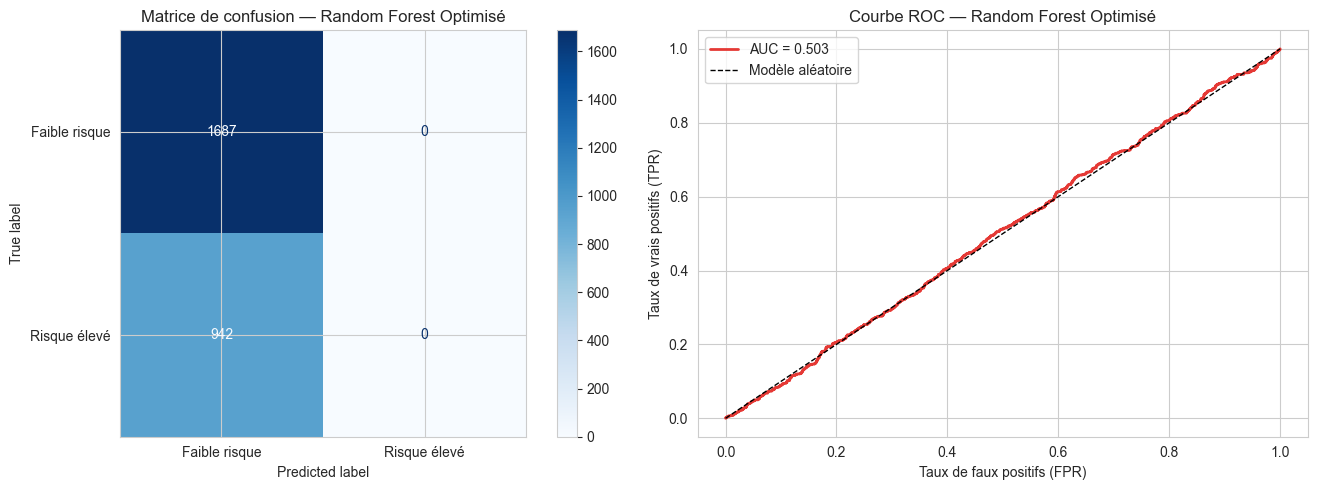

In [29]:
# Évaluer le Random Forest avec les meilleurs hyperparamètres trouvés
res = evaluer_modele(
    "Random Forest Optimisé",
    grd_rf.best_estimator_,   # .best_estimator_ = le modèle avec les meilleurs params
    X_train, y_train, X_test, y_test
)
resultats.append(res)

### 7.2 XGBoost

In [30]:
# ─────────────────────────────────────────────────────────────
# Optimisation des hyperparamètres XGBoost
#
# Paramètres testés :
# n_estimators  : nombre d'arbres (plus = potentiellement meilleur mais plus lent)
# max_depth     : profondeur des arbres (trop profond = overfitting)
# learning_rate : taux d'apprentissage (faible = plus stable, lent)
# subsample     : fraction des données utilisée pour chaque arbre (régularisation)
# ─────────────────────────────────────────────────────────────

params_xgb = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

grd_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    param_grid=params_xgb,
    cv=5,
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1
)

grd_xgb.fit(X_train, y_train)

print("Meilleurs paramètres XGBoost :", grd_xgb.best_params_)
print("Meilleur AUC-ROC (CV)        :", round(grd_xgb.best_score_, 4))

Meilleurs paramètres XGBoost : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Meilleur AUC-ROC (CV)        : 0.5163


  Modèle : XGBoost Optimisé
  Accuracy Train : 0.6616
  Accuracy Test  : 0.6440
  Gap Train-Test : 0.0176  ✓ Stable
  AUC-ROC        : 0.5098
  F1-Score       : 0.0410

               precision    recall  f1-score   support

Faible risque       0.64      0.99      0.78      1687
 Risque élevé       0.59      0.02      0.04       942

     accuracy                           0.64      2629
    macro avg       0.62      0.51      0.41      2629
 weighted avg       0.62      0.64      0.52      2629



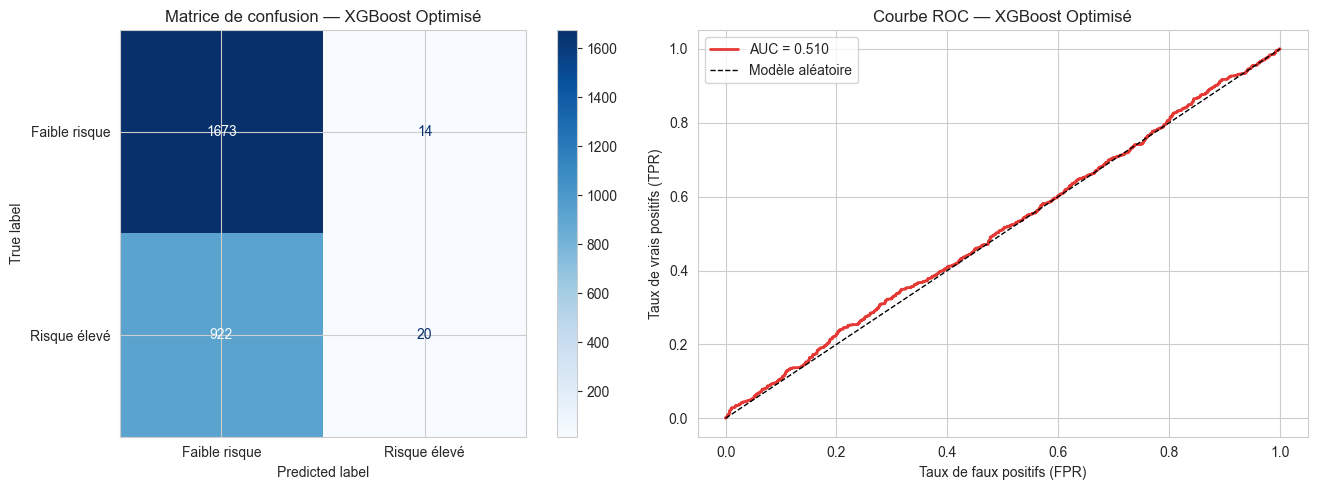

In [31]:
# Évaluer XGBoost avec ses meilleurs hyperparamètres
res = evaluer_modele(
    "XGBoost Optimisé",
    grd_xgb.best_estimator_,
    X_train, y_train, X_test, y_test
)
resultats.append(res)

## 8. Tableau comparatif final

In [32]:
# ─────────────────────────────────────────────────────────────
# Tableau récapitulatif de tous les modèles
# Trié par AUC-ROC décroissant (meilleur modèle en premier)
# ─────────────────────────────────────────────────────────────

df_results = (pd.DataFrame(resultats)
              .sort_values('AUC-ROC', ascending=False)
              .reset_index(drop=True))
df_results.index += 1  # commencer la numérotation à 1

print(df_results.to_string())
print("\n→ Le meilleur modèle est celui avec le plus haut AUC-ROC")

                   Modèle  Acc Train  Acc Test  AUC-ROC  F1-Score
1                 XGBoost     0.7075    0.6417   0.5174    0.1063
2       Gradient Boosting     0.6739    0.6371   0.5173    0.0610
3        XGBoost Optimisé     0.6616    0.6440   0.5098    0.0410
4                     KNN     0.6920    0.5862   0.5071    0.2649
5  Random Forest Optimisé     0.6418    0.6417   0.5030    0.0000
6           Random Forest     1.0000    0.6383   0.4961    0.0537
7   Régression Logistique     0.6418    0.6417   0.4945    0.0000
8           Decision Tree     1.0000    0.5261   0.4915    0.3584

→ Le meilleur modèle est celui avec le plus haut AUC-ROC


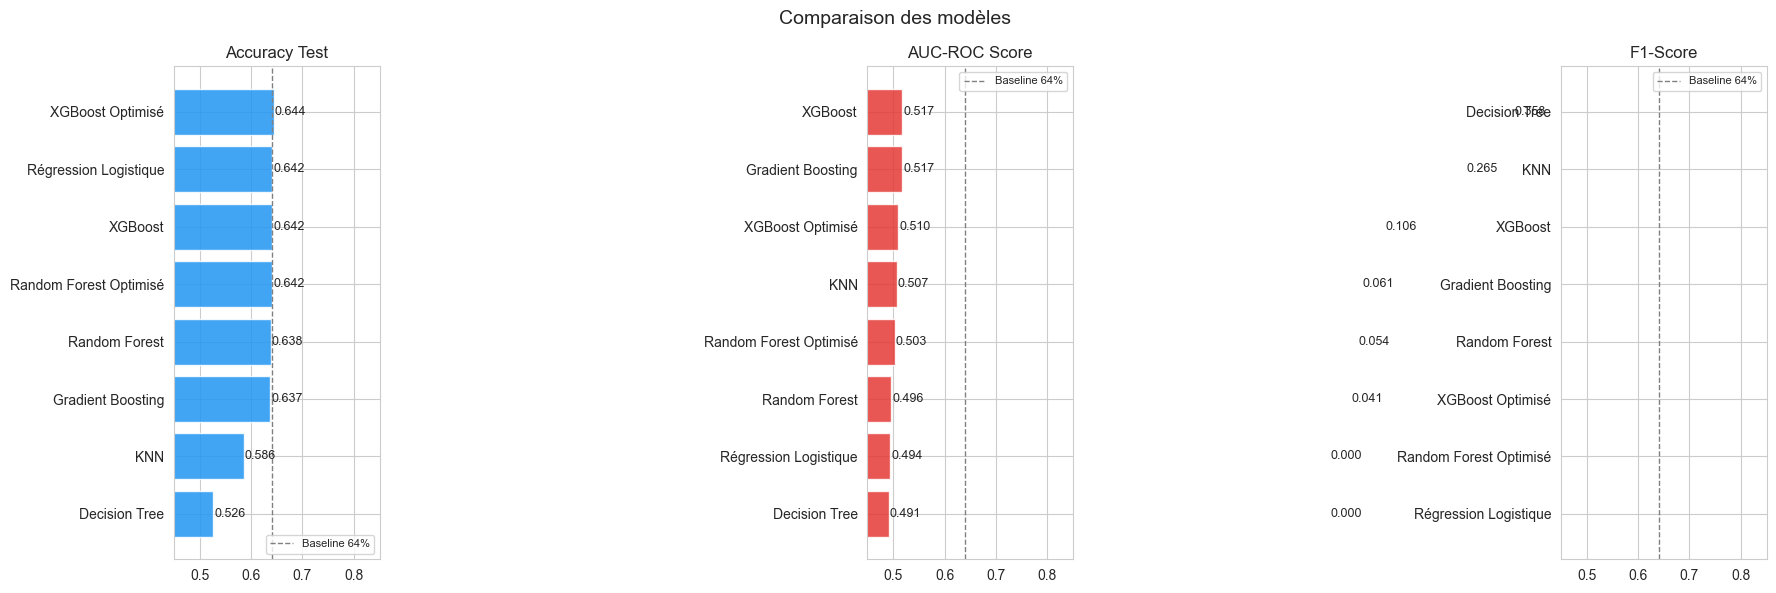

In [33]:
# ─────────────────────────────────────────────────────────────
# Visualisation comparative des métriques pour tous les modèles
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Trois métriques clés à comparer
metrics = ['Acc Test', 'AUC-ROC', 'F1-Score']
titles  = ['Accuracy Test', 'AUC-ROC Score', 'F1-Score']
colors  = ['#2196F3', '#E53935', '#4CAF50']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    # Trier pour avoir le meilleur modèle en haut
    df_sorted = df_results.sort_values(metric, ascending=True)
    axes[i].barh(df_sorted['Modèle'], df_sorted[metric],
                 color=color, alpha=0.85)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_xlim(0.45, 0.85)
    # Ligne pointillée = niveau de référence baseline (64% du notebook original)
    axes[i].axvline(0.64, color='gray', linestyle='--',
                    linewidth=1, label='Baseline 64%')
    # Afficher les valeurs sur chaque barre
    for j, val in enumerate(df_sorted[metric]):
        axes[i].text(val + 0.002, j, f'{val:.3f}', va='center', fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Comparaison des modèles', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Feature Importances — Meilleur modèle

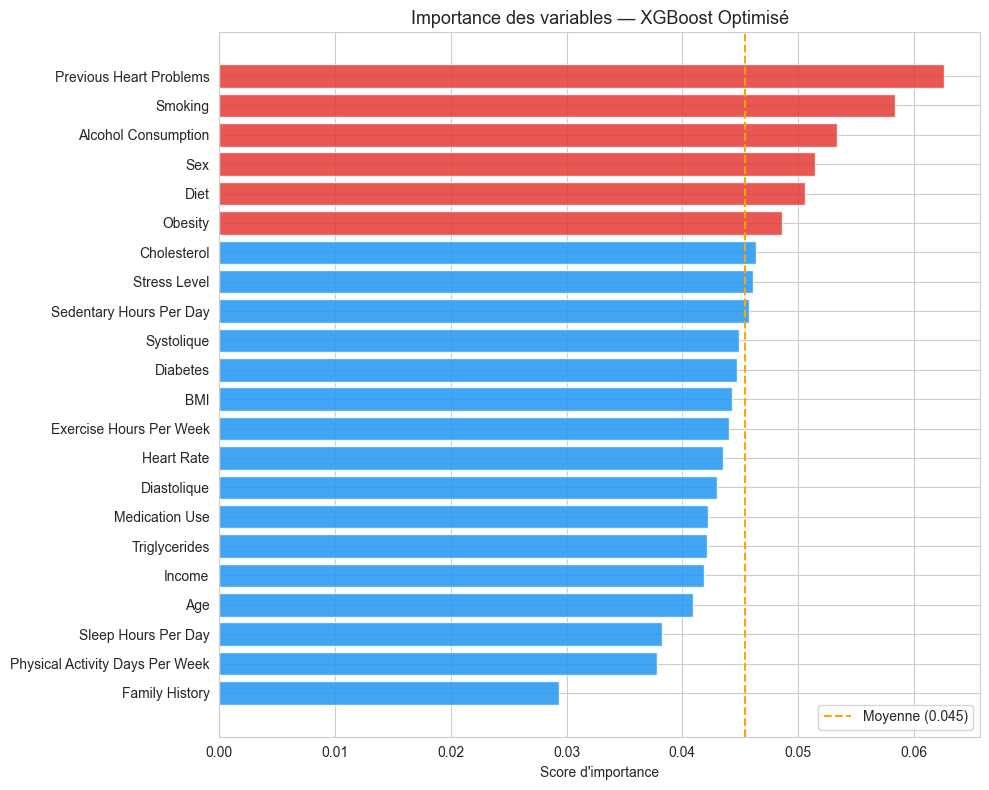

Top 5 variables les plus prédictives :
Previous Heart Problems    0.0626
Smoking                    0.0584
Alcohol Consumption        0.0533
Sex                        0.0515
Diet                       0.0506
dtype: float32

Ces variables sont les plus utiles pour prédire le risque cardiaque


In [34]:
# ─────────────────────────────────────────────────────────────
# FEATURE IMPORTANCES : quelles variables le modèle utilise-t-il le plus ?
#
# Pour XGBoost, l'importance mesure combien de fois une variable
# est utilisée pour faire des coupures dans les arbres, pondéré
# par l'amélioration qu'elle apporte
#
# Les barres rouges = variables au-dessus du 75e percentile d'importance
# Les barres bleues  = variables en dessous
# ─────────────────────────────────────────────────────────────

# Récupérer le meilleur modèle (XGBoost optimisé)
best_model = grd_xgb.best_estimator_

# Créer une série pandas avec les importances et les noms des variables
importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)  # trier pour un graphique horizontal lisible

plt.figure(figsize=(10, 8))

# Colorer en rouge les variables les plus importantes (> Q75)
colors_fi = ['#E53935' if v > importances.quantile(0.75) else '#2196F3'
             for v in importances]

plt.barh(importances.index, importances.values,
         color=colors_fi, alpha=0.85)

# Ligne verticale pour la moyenne des importances
plt.axvline(importances.mean(), color='orange', linestyle='--',
            linewidth=1.5, label=f'Moyenne ({importances.mean():.3f})')

plt.title('Importance des variables — XGBoost Optimisé', fontsize=13)
plt.xlabel('Score d\'importance')
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 variables les plus prédictives :")
print(importances.sort_values(ascending=False).head(5).round(4))
print("\nCes variables sont les plus utiles pour prédire le risque cardiaque")

## 10. Validation croisée finale

AUC-ROC moyen (10-fold CV) : 0.5116
Ecart-type                 : 0.0300
Scores par fold            : [0.5187 0.4747 0.5224 0.4364 0.5302 0.519  0.5185 0.5329 0.5386 0.5244]

Intervalle de confiance ~95% : [0.4517 ; 0.5715]


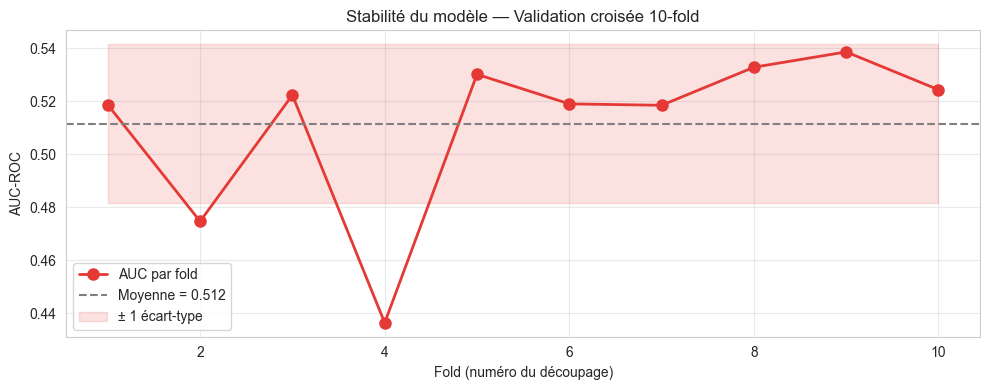

In [35]:
# ─────────────────────────────────────────────────────────────
# VALIDATION CROISÉE 10-FOLD
#
# Principe : découper le dataset en 10 parties égales
# → Entraîner sur 9 parties, tester sur la 10e
# → Répéter 10 fois (chaque partie est testée une fois)
# → Calculer la moyenne et l'écart-type des scores
#
# Avantage : évaluation plus robuste qu'un seul split train/test
# Un écart-type élevé = modèle instable (résultats qui varient beaucoup)
# Un écart-type faible = modèle stable et généralisable
# ─────────────────────────────────────────────────────────────

cv_scores = cross_val_score(
    best_model,       # modèle à évaluer
    X,                # dataset COMPLET (la CV fait ses propres splits)
    y,
    cv=10,            # 10 plis
    scoring='roc_auc',# métrique d'évaluation
    n_jobs=-1         # paralléliser les 10 entraînements
)

print(f"AUC-ROC moyen (10-fold CV) : {cv_scores.mean():.4f}")
print(f"Ecart-type                 : {cv_scores.std():.4f}")
print(f"Scores par fold            : {np.round(cv_scores, 4)}")
print(f"\nIntervalle de confiance ~95% : [{cv_scores.mean() - 2*cv_scores.std():.4f} ; {cv_scores.mean() + 2*cv_scores.std():.4f}]")

# Visualisation de la stabilité du modèle
plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), cv_scores, marker='o',
         color='#E53935', linewidth=2, markersize=8, label='AUC par fold')
plt.axhline(cv_scores.mean(), color='gray', linestyle='--',
            linewidth=1.5, label=f'Moyenne = {cv_scores.mean():.3f}')
# Zone grisée = intervalle de ± 1 écart-type autour de la moyenne
plt.fill_between(range(1, 11),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.15, color='#E53935', label='± 1 écart-type')
plt.xlabel('Fold (numéro du découpage)')
plt.ylabel('AUC-ROC')
plt.title('Stabilité du modèle — Validation croisée 10-fold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 11. Sauvegarde du modèle

In [2]:
# ─────────────────────────────────────────────────────────────
# SAUVEGARDE DU MODÈLE ENTRAÎNÉ
#
# joblib.dump() sérialise l'objet Python en fichier binaire (.pkl)
# Cela permet de réutiliser le modèle sans le réentraîner
# On sauvegarde AUSSI le scaler : pour prédire sur de nouvelles données,
# il faut appliquer exactement le même preprocessing
# ─────────────────────────────────────────────────────────────

# Sauvegarder le meilleur modèle (XGBoost optimisé)
joblib.dump(best_model, 'best_model_heart_attack.pkl')
print("Modèle sauvegardé : best_model_heart_attack.pkl")

# Sauvegarder le scaler (pour prétraiter les nouvelles données de la même façon)
joblib.dump(scaler, 'scaler_heart_attack.pkl')
print("Scaler sauvegardé : scaler_heart_attack.pkl")

NameError: name 'joblib' is not defined

In [1]:
best_model.get_booster().save_model('booster_heart_attack.json')
print("Modèle exporté en format natif JSON")

NameError: name 'best_model' is not defined

In [37]:
# ─────────────────────────────────────────────────────────────
# VÉRIFICATION DU RECHARGEMENT
#
# S'assurer que le modèle sauvegardé fonctionne correctement
# après rechargement (le score doit être identique)
# ─────────────────────────────────────────────────────────────

# Recharger le modèle depuis le fichier
model_loaded  = joblib.load('best_model_heart_attack.pkl')
scaler_loaded = joblib.load('scaler_heart_attack.pkl')

# Vérifier que les prédictions sont identiques
y_check = model_loaded.predict(X_test)
print(f"Accuracy après rechargement : {accuracy_score(y_test, y_check):.4f}")
print("✓ Le modèle rechargé produit les mêmes résultats")
print("\nPour utiliser ce modèle sur de nouvelles données :")
print("  1. model = joblib.load('best_model_heart_attack.pkl')")
print("  2. scaler = joblib.load('scaler_heart_attack.pkl')")
print("  3. X_new_scaled = scaler.transform(X_new[cols_scale])")
print("  4. prediction = model.predict(X_new_scaled)")

Accuracy après rechargement : 0.6440
✓ Le modèle rechargé produit les mêmes résultats

Pour utiliser ce modèle sur de nouvelles données :
  1. model = joblib.load('best_model_heart_attack.pkl')
  2. scaler = joblib.load('scaler_heart_attack.pkl')
  3. X_new_scaled = scaler.transform(X_new[cols_scale])
  4. prediction = model.predict(X_new_scaled)


## 12. Conclusion

### Corrections apportées vs notebook original

| Problème original | Correction appliquée |
|---|---|
| Target Encoding avec data leakage | LabelEncoder propre avant le split |
| Cellule MinMaxScaler non exécutée | RobustScaler intégré dans le pipeline |
| Pas de `stratify=y` dans le split | `stratify=y` ajouté |
| Blood Pressure en ratio | Séparation Systolique / Diastolique |
| Aucune matrice de confusion | Matrice de confusion pour chaque modèle |
| AUC-ROC non analysée | Courbe ROC + score AUC affichés systématiquement |
| Pas de F1-Score | F1-Score calculé pour chaque modèle |
| Pas de XGBoost ni Gradient Boosting | Ajoutés au comparatif |
| GridSearchCV sur accuracy | GridSearchCV sur AUC-ROC |
| Pas de validation croisée finale | 10-fold CV sur le meilleur modèle |
| Aucune sauvegarde du modèle | joblib.dump() modèle + scaler |

### Rappel
> Ce modèle est un outil d'aide à la décision — il ne remplace pas un diagnostic médical qualifié.